In [1]:
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from mlxtend.plotting import plot_decision_regions

In [2]:
np.random.seed(42)
X,y = make_circles(n_samples=500, noise=0.35, factor=0.1, random_state=42)

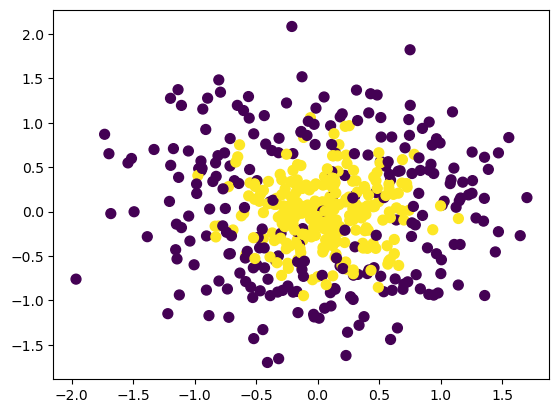

In [3]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='viridis')

In [4]:
from sklearn.model_selection import cross_val_score

In [5]:
ada = AdaBoostClassifier()

np.mean(cross_val_score(ada, X, y, cv=10, scoring='accuracy'))

d:\admin\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
d:\admin\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
d:\admin\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
d:\admin\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
d:\admin\anaconda3\Lib\site-packages

0.786

In [6]:
ada.fit(X, y)

d:\admin\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoostClassifier()

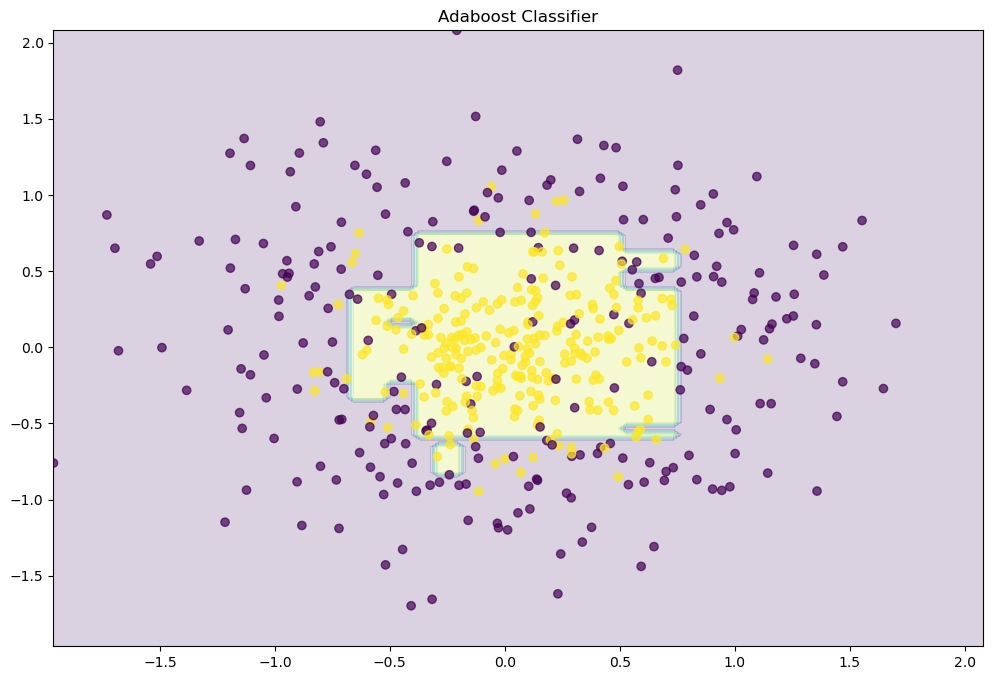

In [8]:
def plot_decision_boundary(clf):
    plt.figure(figsize=(12, 8))
    x_range = np.linspace(X.min(), X.max(), 100)
    xx1, xx2 = np.meshgrid(x_range, x_range)
    y_hat = clf.predict(np.c_[xx1.ravel(), xx2.ravel()])
    y_hat = y_hat.reshape(xx1.shape)
    plt.contourf(xx1, xx2, y_hat, alpha=0.2)
    plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', alpha=.7)
    plt.title("Adaboost Classifier")
    plt.show()
    
plot_decision_boundary(ada)

d:\admin\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


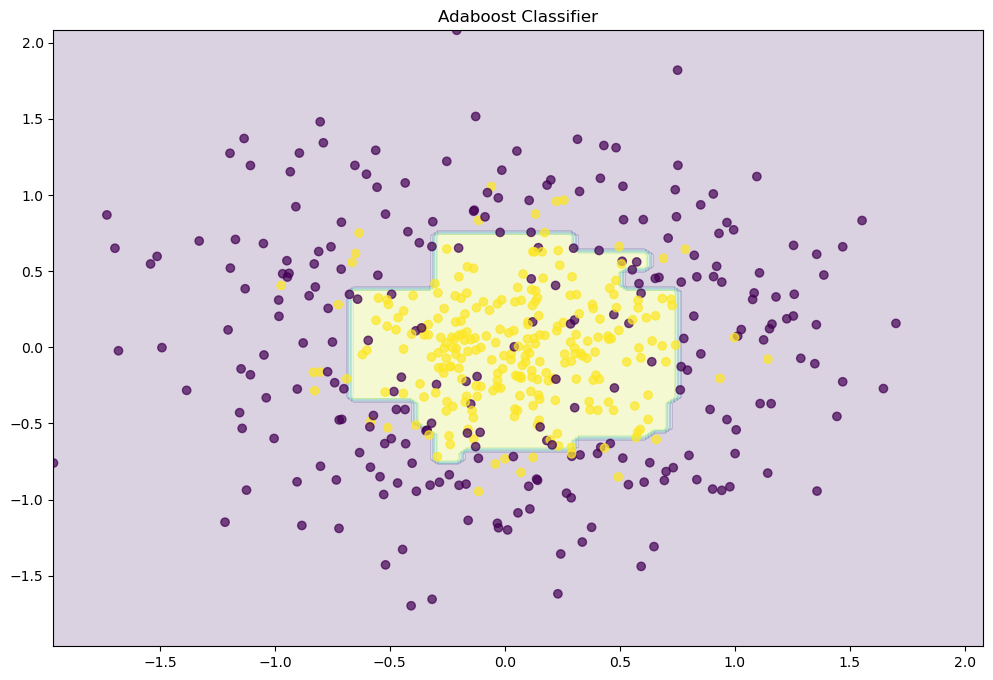

In [12]:
ada = AdaBoostClassifier(n_estimators = 500, learning_rate = 0.1 )
ada.fit(X, y)
plot_decision_boundary(ada)

In [13]:
from sklearn.model_selection import GridSearchCV

grid = dict()
grid['n_estimators'] = [600, 1000, 1200, 1500, 2000]
grid['learning_rate'] = [0.01, 0.1, 0.5, 1.0, 2.0]
grid['algorithm'] = ['SAMME', 'SAMME.R']

grid_search = GridSearchCV(estimator=AdaBoostClassifier(),
                         param_grid=grid,
                         scoring='accuracy',
                         cv=10,
                         verbose=1,
                         n_jobs=-1)

In [14]:
grid_search.fit(X, y)

Fitting 10 folds for each of 50 candidates, totalling 500 fits


GridSearchCV(cv=10, estimator=AdaBoostClassifier(), n_jobs=-1,
             param_grid={'algorithm': ['SAMME', 'SAMME.R'],
                         'learning_rate': [0.01, 0.1, 0.5, 1.0, 2.0],
                         'n_estimators': [600, 1000, 1200, 1500, 2000]},
             scoring='accuracy', verbose=1)

In [15]:
grid_search.best_params_

{'algorithm': 'SAMME', 'learning_rate': 0.1, 'n_estimators': 600}